# 06. Business Recommendation Summary

This notebook summarizes the Diabetes Peer Support A/B testing project and converts the analytical findings into a business recommendation.

The main questions are:

1. Did Diabetes Peer Support improve diabetes testing compliance?
2. Was the result meaningful enough to support program expansion?
3. Which member groups may be best suited for future targeting?
4. What operational issues should be addressed before scaling?
5. What should the next experiment test?

This notebook is written for a healthcare analytics, operations, and leadership audience.

## 1. Imports

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 2. Load Dataset

In [2]:
# Define the project-relative path to the synthetic A/B testing dataset
DATA_PATH = Path("../data/raw/mock_diabetes_peer_support_ab_test.csv")

# Load the generated dataset into a pandas DataFrame
df = pd.read_csv(DATA_PATH)

# Confirm the number of rows and columns
df.shape

(4000, 33)

## 3. Confirm Experiment Groups

In [3]:
# Confirm randomized group counts before summarizing results
df["experiment_group"].value_counts()

experiment_group
Diabetes Peer Support    2078
Standard Outreach        1922
Name: count, dtype: int64

## 4. Executive Summary

The Diabetes Peer Support program was evaluated using a synthetic randomized A/B testing framework.

Members were assigned to either:

- Standard Outreach
- Diabetes Peer Support

The primary business outcome was binary diabetes testing compliance.

The primary A/B test showed that members assigned to Diabetes Peer Support had higher compliance than members assigned to Standard Outreach.

Key result:

- Standard Outreach compliance rate: 37.6%
- Diabetes Peer Support compliance rate: 42.3%
- Absolute lift: 4.7 percentage points
- Relative lift: 12.6%
- Two-proportion z-test p-value: 0.0023
- 95% confidence interval for absolute lift: 1.7 to 7.8 percentage points

The program should be considered for targeted expansion, especially if operational funnel performance can be improved and future monitoring confirms similar results in real-world implementation.

## 5. Recalculate Main A/B Results

In [4]:
# Summarize primary outcomes by randomized experiment group
ab_summary = (
    df
    .groupby("experiment_group")
    .agg(
        members=("member_id", "count"),
        avg_compliance_rate=("diabetes_testing_compliance_rate", "mean"),
        binary_compliance_rate=("diabetes_testing_compliant", "mean")
    )
    .reset_index()
)

# Convert outcome rates to percentages for business readability
ab_summary["avg_compliance_rate_pct"] = ab_summary["avg_compliance_rate"] * 100
ab_summary["binary_compliance_rate_pct"] = ab_summary["binary_compliance_rate"] * 100

# Round values for cleaner reporting
ab_summary = ab_summary.round({
    "avg_compliance_rate": 3,
    "binary_compliance_rate": 3,
    "avg_compliance_rate_pct": 1,
    "binary_compliance_rate_pct": 1
})

ab_summary

,experiment_group,members,avg_compliance_rate,binary_compliance_rate,avg_compliance_rate_pct,binary_compliance_rate_pct
0,Diabetes Peer Support,2078,0.745,0.423,74.5,42.3
1,Standard Outreach,1922,0.713,0.376,71.3,37.6


## 6. Calculate Lift

In [5]:
# Extract control and treatment compliance rates
control_binary_rate = ab_summary.loc[
    ab_summary["experiment_group"] == "Standard Outreach",
    "binary_compliance_rate"
].iloc[0]

treatment_binary_rate = ab_summary.loc[
    ab_summary["experiment_group"] == "Diabetes Peer Support",
    "binary_compliance_rate"
].iloc[0]

control_avg_rate = ab_summary.loc[
    ab_summary["experiment_group"] == "Standard Outreach",
    "avg_compliance_rate"
].iloc[0]

treatment_avg_rate = ab_summary.loc[
    ab_summary["experiment_group"] == "Diabetes Peer Support",
    "avg_compliance_rate"
].iloc[0]

# Calculate absolute and relative lift for binary compliance
binary_absolute_lift = treatment_binary_rate - control_binary_rate
binary_relative_lift = binary_absolute_lift / control_binary_rate

# Calculate absolute and relative lift for average compliance rate
avg_absolute_lift = treatment_avg_rate - control_avg_rate
avg_relative_lift = avg_absolute_lift / control_avg_rate

# Create a business-friendly lift summary
lift_summary = pd.DataFrame({
    "metric": [
        "Binary Compliance Rate",
        "Average Compliance Rate"
    ],
    "standard_outreach": [
        control_binary_rate,
        control_avg_rate
    ],
    "diabetes_peer_support": [
        treatment_binary_rate,
        treatment_avg_rate
    ],
    "absolute_lift": [
        binary_absolute_lift,
        avg_absolute_lift
    ],
    "relative_lift": [
        binary_relative_lift,
        avg_relative_lift
    ]
})

# Convert rates to percentages for reporting
for col in ["standard_outreach", "diabetes_peer_support", "absolute_lift", "relative_lift"]:
    lift_summary[f"{col}_pct"] = lift_summary[col] * 100

# Round final display values
lift_summary = lift_summary.round(3)

lift_summary

,metric,standard_outreach,diabetes_peer_support,absolute_lift,relative_lift,standard_outreach_pct,diabetes_peer_support_pct,absolute_lift_pct,relative_lift_pct
0,Binary Compliance Rate,0.376,0.423,0.047,0.125,37.6,42.3,4.7,12.500
1,Average Compliance Rate,0.713,0.745,0.032,0.045,71.3,74.5,3.2,4.488


## 7. A/B Result Visualization

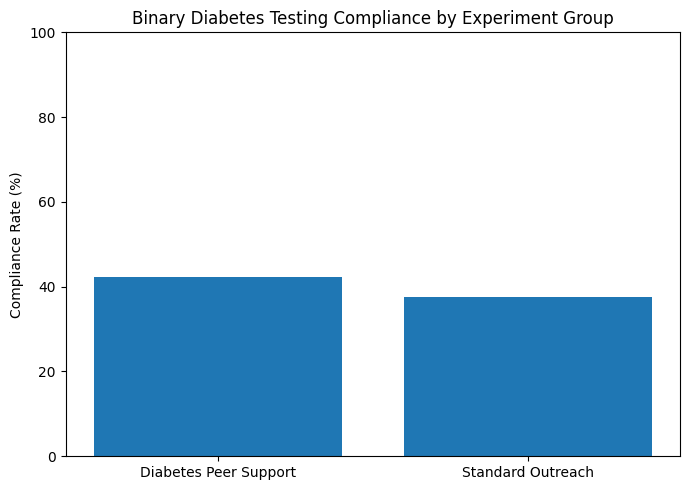

In [6]:
# Visualize binary compliance rate by randomized group
plt.figure(figsize=(7, 5))
plt.bar(
    ab_summary["experiment_group"],
    ab_summary["binary_compliance_rate_pct"]
)

plt.title("Binary Diabetes Testing Compliance by Experiment Group")
plt.ylabel("Compliance Rate (%)")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

## 8. A/B Result Interpretation

The intent-to-treat A/B result showed higher diabetes testing compliance among members assigned to Diabetes Peer Support compared with members assigned to Standard Outreach.

Because members were compared based on randomized assignment, this is the cleanest estimate for the program strategy in this synthetic experiment.

This estimate reflects the effect of being assigned to the Diabetes Peer Support outreach strategy, not the isolated effect of attending peer-support sessions.

## 9. Funnel Summary

In [7]:
# Keep only members assigned to Diabetes Peer Support for funnel analysis
treatment = df[df["experiment_group"] == "Diabetes Peer Support"].copy()

# Calculate major funnel counts
assigned_count = len(treatment)
invited_count = treatment["program_invited"].sum()
enrolled_count = treatment["program_enrolled"].sum()
attended_count = treatment["attended_at_least_one_session"].sum()

# Summarize funnel counts and rates
funnel_summary = pd.DataFrame({
    "funnel_stage": [
        "Assigned to Peer Support",
        "Invited",
        "Enrolled",
        "Attended ≥1 Session"
    ],
    "member_count": [
        assigned_count,
        invited_count,
        enrolled_count,
        attended_count
    ],
    "share_of_assigned": [
        assigned_count / assigned_count,
        invited_count / assigned_count,
        enrolled_count / assigned_count,
        attended_count / assigned_count
    ]
})

# Convert shares to percentages for reporting
funnel_summary["share_of_assigned_pct"] = funnel_summary["share_of_assigned"] * 100

# Round final display values
funnel_summary = funnel_summary.round({
    "share_of_assigned": 3,
    "share_of_assigned_pct": 1
})

funnel_summary

,funnel_stage,member_count,share_of_assigned,share_of_assigned_pct
0,Assigned to Peer Support,2078,1.000,100.0
1,Invited,1758,0.846,84.6
2,Enrolled,765,0.368,36.8
3,Attended ≥1 Session,280,0.135,13.5


## 10. Funnel Visualization

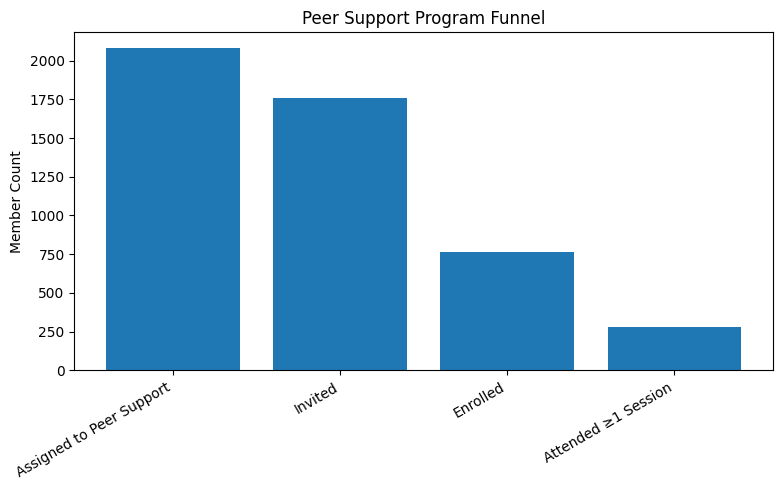

In [8]:
# Visualize member retention across the peer-support funnel
plt.figure(figsize=(8, 5))
plt.bar(
    funnel_summary["funnel_stage"],
    funnel_summary["member_count"]
)

plt.title("Peer Support Program Funnel")
plt.ylabel("Member Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 11. Funnel Interpretation

The funnel analysis shows whether the program can convert randomized assignment into actual participation.

This matters because even a useful intervention can have limited business impact if too few members enroll or attend.

Program leaders should review where the largest drop-off occurs and decide whether the bottleneck is outreach, enrollment, first-session attendance, or continued engagement.

## 12. SDOH Risk Segment Summary

In [9]:
# Create SDOH risk groups for targeting analysis
df["sdoh_risk_group"] = pd.qcut(
    df["sdoh_risk_score"],
    q=3,
    labels=["Low SDOH Risk", "Medium SDOH Risk", "High SDOH Risk"]
)

# Summarize outcomes by SDOH risk group and randomized assignment
sdoh_summary = (
    df
    .groupby(["sdoh_risk_group", "experiment_group"], observed=True)
    .agg(
        members=("member_id", "count"),
        avg_compliance_rate=("diabetes_testing_compliance_rate", "mean"),
        binary_compliance_rate=("diabetes_testing_compliant", "mean")
    )
    .reset_index()
)

sdoh_summary

,sdoh_risk_group,experiment_group,members,avg_compliance_rate,binary_compliance_rate
0,Low SDOH Risk,Diabetes Peer Support,693,0.790870,0.484848
1,Low SDOH Risk,Standard Outreach,647,0.750216,0.431221
2,Medium SDOH Risk,Diabetes Peer Support,693,0.768253,0.461760
3,Medium SDOH Risk,Standard Outreach,636,0.740653,0.421384
4,High SDOH Risk,Diabetes Peer Support,692,0.674447,0.322254
5,High SDOH Risk,Standard Outreach,639,0.646380,0.273865


## 13. SDOH Lift Table


In [10]:
# Pivot SDOH summary to compare treatment and control within each risk group
sdoh_lift = sdoh_summary.pivot(
    index="sdoh_risk_group",
    columns="experiment_group",
    values="binary_compliance_rate"
).reset_index()

# Calculate binary compliance lift within each SDOH risk group
sdoh_lift["binary_absolute_lift"] = (
    sdoh_lift["Diabetes Peer Support"] -
    sdoh_lift["Standard Outreach"]
)

# Convert rates to percentages for readability
sdoh_lift["standard_outreach_pct"] = sdoh_lift["Standard Outreach"] * 100
sdoh_lift["diabetes_peer_support_pct"] = sdoh_lift["Diabetes Peer Support"] * 100
sdoh_lift["binary_absolute_lift_pp"] = sdoh_lift["binary_absolute_lift"] * 100

# Round final display values
sdoh_lift = sdoh_lift.round(1)

sdoh_lift

experiment_group,sdoh_risk_group,Diabetes Peer Support,Standard Outreach,binary_absolute_lift,standard_outreach_pct,diabetes_peer_support_pct,binary_absolute_lift_pp
0,Low SDOH Risk,0.5,0.4,0.1,43.1,48.5,5.4
1,Medium SDOH Risk,0.5,0.4,0.0,42.1,46.2,4.0
2,High SDOH Risk,0.3,0.3,0.0,27.4,32.2,4.8


## 14. SDOH Lift Visualization

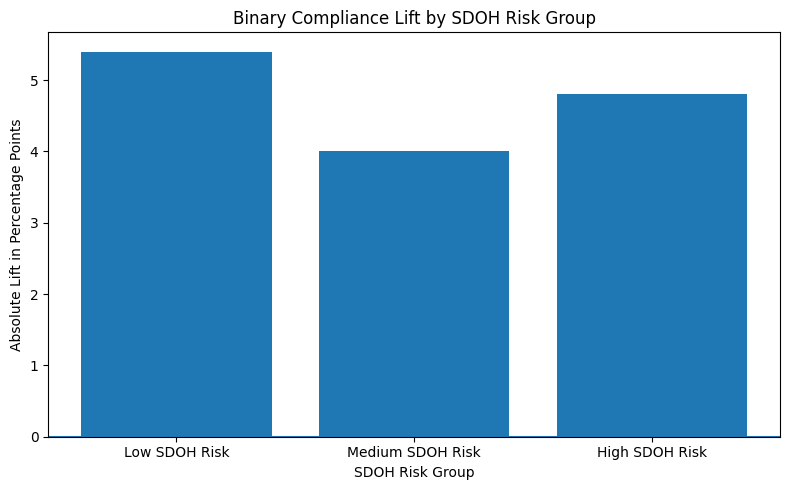

In [11]:
# Visualize binary compliance lift by SDOH risk group
plt.figure(figsize=(8, 5))
plt.bar(
    sdoh_lift["sdoh_risk_group"].astype(str),
    sdoh_lift["binary_absolute_lift_pp"]
)

plt.title("Binary Compliance Lift by SDOH Risk Group")
plt.xlabel("SDOH Risk Group")
plt.ylabel("Absolute Lift in Percentage Points")
plt.axhline(0)
plt.tight_layout()
plt.show()

## 15. Targeting Interpretation

The SDOH segment analysis helps identify which members may be useful candidates for future targeting.

In this notebook, Diabetes Peer Support showed positive observed binary compliance lift across SDOH risk groups.

These results suggest that SDOH risk may be useful for outreach prioritization, but the subgroup results should be interpreted cautiously.

Segment-level findings are exploratory. They should guide future targeting strategy, not replace the overall intent-to-treat A/B result from Notebook 02.

Future targeting decisions should also consider operational feasibility, enrollment conversion, attendance rates, staffing capacity, and cost per additional compliant member.

## 16. Recommendation Decision Framework

A program expansion decision should consider four factors:

1. Effectiveness  
   Did Diabetes Peer Support improve diabetes testing compliance?

2. Operational feasibility  
   Can the program enroll and retain enough members?

3. Targeting value  
   Are there member segments where the program appears especially useful?

4. Cost and scalability  
   Can the program be expanded without excessive staffing, vendor, or coordination burden?

## 17. Recommendation Summary Table

In [12]:
# Create an executive recommendation summary
recommendation_summary = pd.DataFrame({
    "decision_area": [
        "Effectiveness",
        "Operational Feasibility",
        "Targeting Value",
        "Scalability"
    ],
    "assessment": [
        "Positive A/B testing result",
        "Depends on funnel conversion and attendance",
        "Potentially useful for SDOH-informed outreach prioritization",
        "Recommend targeted expansion before full-scale rollout"
    ],
    "business_implication": [
        "Peer support was associated with higher diabetes testing compliance versus standard outreach in the randomized synthetic experiment",
        "Program impact depends on invitation, enrollment, and attendance rates",
        "Targeting may improve outreach efficiency and reduce low-yield program effort",
        "Scale gradually while monitoring cost, staffing, member experience, and compliance outcomes"
    ]
})

recommendation_summary

,decision_area,assessment,business_implication
0,Effectiveness,Positive A/B testing result,Peer support was associated with higher diabet...
1,Operational Feasibility,Depends on funnel conversion and attendance,"Program impact depends on invitation, enrollme..."
2,Targeting Value,Potentially useful for SDOH-informed outreach ...,Targeting may improve outreach efficiency and ...
3,Scalability,Recommend targeted expansion before full-scale...,"Scale gradually while monitoring cost, staffin..."


## 18. Final Business Recommendation

Recommendation: Expand Diabetes Peer Support in a targeted and monitored way.

The program should not be rolled out blindly to every diabetic member. Instead, the next phase should prioritize members who are more likely to benefit from additional behavioral and social support.

Recommended target groups:

- Members with incomplete prior diabetes testing compliance
- Members with moderate to high SDOH risk
- Members with specific barriers that may be addressable through peer support, reminders, scheduling flexibility, or care-navigation support
- Members with enough baseline engagement to realistically enroll and attend

Operational priorities before expansion:

- Improve enrollment conversion
- Improve first-session attendance
- Monitor session capacity and peer-leader availability
- Offer virtual or flexible participation options
- Track outcomes by SDOH and engagement segment

The best business decision is targeted expansion with continued measurement, not immediate full-population rollout.

## 19. Limitations

This project uses synthetic data, so the results should be interpreted as a portfolio analytics demonstration rather than real-world clinical evidence.

Key limitations:

1. The dataset is synthetic and does not represent actual patient outcomes.
2. Testing compliance is an operational quality measure, not direct proof of improved health.
3. Attendance analysis is not causal because attendance is selective.
4. Segment analysis is exploratory and may be noisy in smaller subgroups.
5. Cost-effectiveness was not directly measured.
6. Real-world implementation would require monitoring staffing, peer-leader quality, member trust, language access, scheduling, and care-team coordination.
7. This notebook summarizes results from earlier analyses and does not rerun every statistical test or adjusted model.

## 20. Next Experiment Recommendation

The next experiment should test a more targeted version of the program.

Recommended design:

- Population: diabetic members with incomplete prior testing compliance and moderate-to-high SDOH risk
- Control: Standard Outreach
- Treatment: Diabetes Peer Support plus enhanced enrollment support
- Primary outcome: binary diabetes testing compliance
- Secondary outcomes: average diabetes testing compliance rate, enrollment rate, attendance rate, no-show rate, and cost per additional compliant member

Recommended improvement:

Add an operational enhancement such as:

- reminder calls,
- virtual session option,
- language-matched peer leaders,
- transportation support,
- simplified enrollment workflow,
- or care-manager referral.

The next test should measure not only whether peer support works, but which version of peer support is most scalable and cost-effective.

## 21. Portfolio Project Closeout

This project demonstrates a complete healthcare A/B testing workflow:

1. Synthetic healthcare data generation
2. Randomization balance check
3. Intent-to-treat A/B testing
4. Peer-support funnel analysis
5. SDOH segment analysis
6. Adjusted sensitivity analysis
7. Business recommendation summary

The project is designed to show both technical analysis and healthcare business judgment.

The main analytical conclusion is that Diabetes Peer Support improved diabetes testing compliance in the synthetic randomized experiment.

The main business conclusion is that targeted expansion is more appropriate than full-population rollout.